In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV


In [29]:
X_train = joblib.load('../data/X_train.pkl')
X_test = joblib.load('../data/X_test.pkl')
y_train = joblib.load('../data/y_train.pkl')
y_test = joblib.load('../data/y_test.pkl')


In [30]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (15703, 12)
X_test shape: (3926, 12)
y_train shape: (15703, 1)
y_test shape: (3926, 1)


In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [32]:
y_pred = model.predict(X_test)

In [33]:
MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)

In [34]:
print(f"MAE: {MAE:.4f}")
print(f"RMSE:{RMSE:.4f}")
print(f"R2: {R2:.4f}")

MAE: 0.4496
RMSE:0.6276
R2: 0.6040


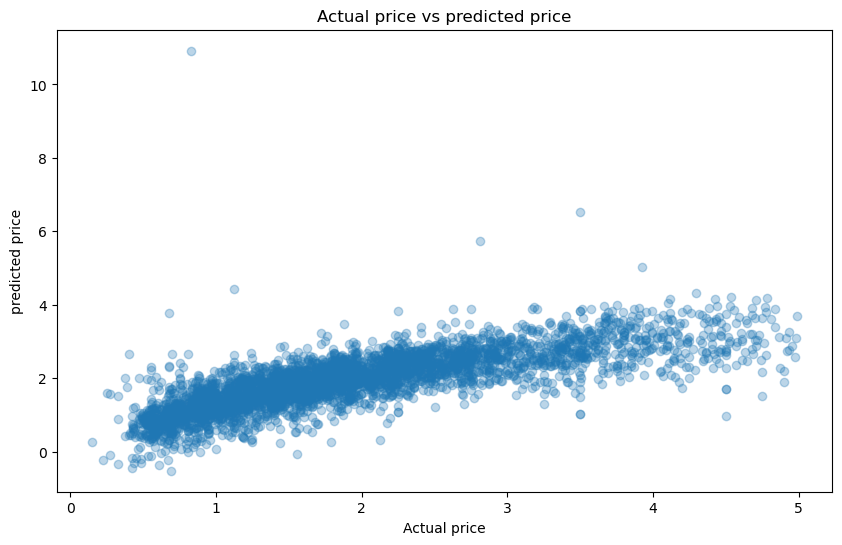

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual price')
plt.ylabel('predicted price')
plt.title('Actual price vs predicted price')
plt.show()

## Day 8: What I understood 

- Linear regression Baseline : MAE = 0.4496, RMSe =0.6276, R2 = 0.6040.
- Model struggles with very cheap (0-1) and expensive (3-5) houses.
- Best predictions int the middle range(1-3).
- why model predict wrong on 3-5 meand  i ahve delted some rows which are above 500k model was trained under less data.

## Day 9 - Import All 5 models

In [36]:
models = {
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    MAE = mean_absolute_error(y_test, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    R2 = r2_score(y_test, y_pred)
    
    print(f"{name}: MAE={MAE:.4f}, RMSE={RMSE:.4f}, R2={R2:.4f}")

Ridge: MAE=0.4496, RMSE=0.6275, R2=0.6040
Lasso: MAE=0.8025, RMSE=0.9972, R2=-0.0000
Decision Tree: MAE=0.4638, RMSE=0.6898, R2=0.5214


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest: MAE=0.3322, RMSE=0.4854, R2=0.7631


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Gradient Boosting: MAE=0.3638, RMSE=0.5150, R2=0.7333


## What I understood After Day 9 
- After training 5 models 
- I get to know that 2  models Predicited far much better then other models.
- 1. Random Forest (MAE = 0,3329, RMSE= 0.4859, R2= 0.76)
- 2. Gradient Boosting (MAE=0.3637, RMSe= 0.5148, R2=0.73)
- But overall Random Forest has upper hand with R2 = 76%

## Day 10 - Cross Validation

In [37]:
rf_model = RandomForestRegressor()
scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print(f"Random Forest: {scores}")
print(f"Average:{scores.mean():.4f}")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

Random Forest: [0.7859521  0.77460186 0.76456497 0.7836211  0.78626403]
Average:0.7790


In [38]:
gb_model = GradientBoostingRegressor()
scores = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='r2')
print(f"Gradient Boosting:{scores}")
print(f"Average: {scores.mean():.4f}")


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y w

Gradient Boosting:[0.77071175 0.75425977 0.74293619 0.76539319 0.76071061]
Average: 0.7588


## Day 10 - What  I understood
- Cross validation results - I have cross validatte with 2 mmodels which have more R2 , random forest and Gradient boosting I have upper hand with Random Forest with - 0.7792  and gradient boosting is 0.7588

## Day - 11 hyperparameters tuning

In [39]:
param_grd = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

In [40]:
rf = RandomForestRegressor()
grid_search = GridSearchCV(rf, param_grd, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [41]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best r2 scores: {grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}
Best r2 scores: 0.7773


## Day 11 - What I understood
- Used Gridsearch cv with 27 combinations (3*3*3) and 5-fold cv.
- Best prarmeters found:
- 1. MAx_depth = 15
- 2. min_samples = 2
- 3. n_estimators = 300

- best R2 = 0.7776 

## Day 12 - Train the model with best parameters

In [42]:
final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=2,
    random_state=42
)
final_model.fit(X_train, y_train)
print(f"finalmodel trained")


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


finalmodel trained


In [43]:
y_pred_final = final_model.predict(X_test)

MAE = mean_absolute_error(y_test, y_pred_final)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred_final))
R2 = r2_score(y_test, y_pred_final)

print(f"MAE: {MAE:.4f}")
print(f"RMSE: {RMSE:.4f}")
print(f"r2: {R2:.4f}")

MAE: 0.3341
RMSE: 0.4880
r2: 0.7606


In [44]:
joblib.dump(final_model, '../models/final_model.pkl')
print("Model saved!")

Model saved!


## Day 12 - what I undestood 
- I have trained final model .
- I have trained fianl model with parameters ,And tested the model, I got MAE= 0.3342, RMSE = 0.4880, R2=0.7606.
- But , i dont see much difference in R2.

## Day 13 - Detailed Evalution!
- Today I'm going to check whther eere model is going to win and where it loses .

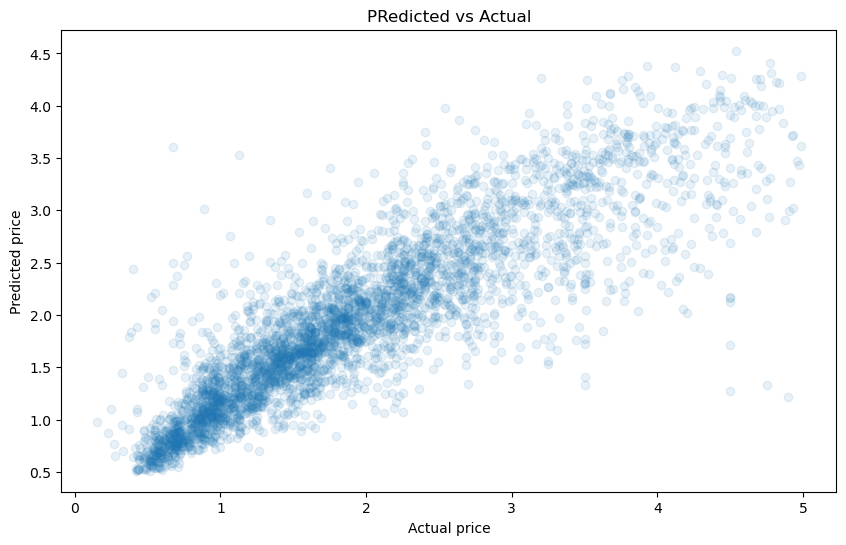

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.1)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("PRedicted vs Actual")
plt.show()

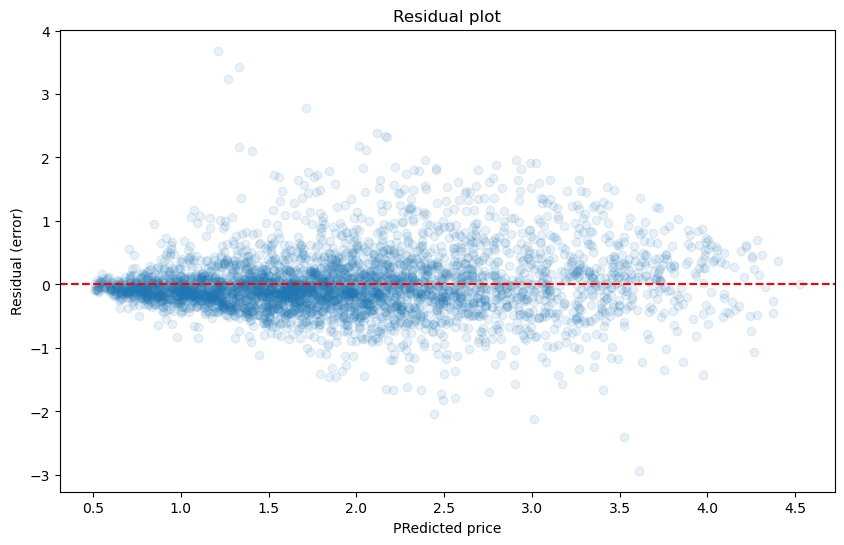

In [46]:
# step 2 - Residual plot
residuals = y_test.values.ravel() - y_pred_final

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_final, residuals, alpha=0.1)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("PRedicted price")
plt.ylabel("Residual (error)")
plt.title("Residual plot")
plt.show()

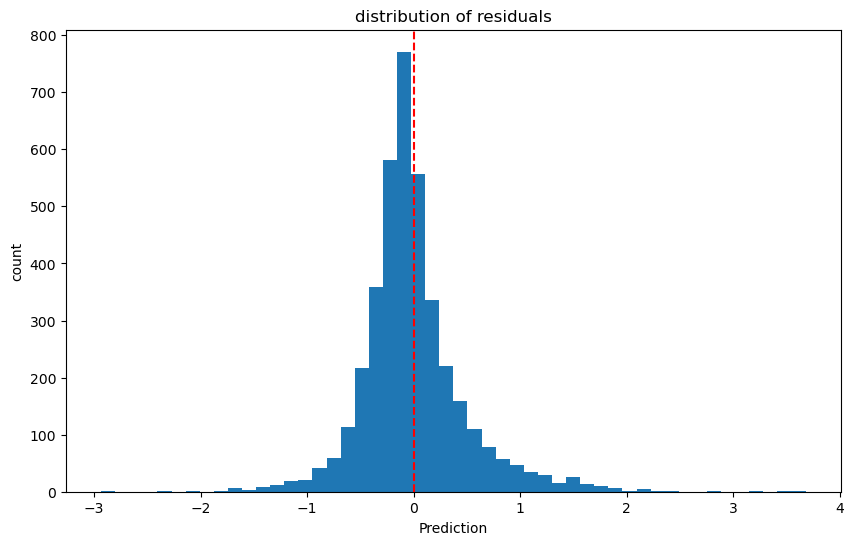

In [47]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50)
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel("Prediction")
plt.ylabel("count")
plt.title("distribution of residuals")
plt.show()

In [48]:
abosulte_dif = abs(residuals)

results_df = pd.DataFrame({'Actual': y_test.values.ravel(), 'predicted': y_pred_final, 'error': abosulte_dif})

results_df.nlargest(10,'error')


,Actual,predicted,error
1759,4.896,1.213809,3.682191
33,4.750,1.328926,3.421074
2806,4.500,1.268044,3.231956
3127,0.675,3.609570,2.934570
2853,4.500,1.712557,2.787443
760,1.125,3.524287,2.399287
2739,4.500,2.120486,2.379514
3576,4.500,2.162070,2.337930
3283,4.500,2.173090,2.326910
1467,4.200,2.014587,2.185413


In [49]:
results_df['PriceRange'] = pd.cut(results_df['Actual'],
                                  bins=[0, 1.0, 2.0, 3.5, 5.0],
                                  labels=['Budget', 'Medium', 'Expensive', 'Luxury'])

print(results_df.groupby('PriceRange')['error'].mean())


PriceRange
Budget       0.253763
Medium       0.255788
Expensive    0.365577
Luxury       0.769605
Name: error, dtype: float64


/var/folders/rg/kqh6208j2tndg1mq33rknf7c0000gn/T/ipykernel_76500/3479096309.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(results_df.groupby('PriceRange')['error'].mean())


## Day 13 - Detailed Evaluation

- Predicted vs Actual plot: model follows diagonal but struggles at high prices
- Residual plot: errors spread wider for expensive houses
- Residual distribution: slight left shift — model slightly overpredicts
- Worst 10 predictions: all luxury houses (4.0-4.9) with errors of $200K-$368K
- Bucketing: Luxury houses (3.5-5.0) have highest average error

Main finding: Model struggles most with luxury houses due to limited training data in that range!"

## Day 14- Feature importance
- Here i going to know which columns make model to predict house price we are going to check today .

In [50]:
importances = final_model.feature_importances_
feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 
                 'Population', 'AveOccup', 'Latitude', 'Longitude',
                 'RoomsPerHousehold', 'BedroomPerRoom', 
                 'PopulationPerHousehold', 'Distance_from_coast']


In [51]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
    })

In [52]:
importance_df.sort_values('Importance', ascending=True)


,Feature,Importance
4,Population,0.015077
10,PopulationPerHousehold,0.017372
3,AveBedrms,0.018636
2,AveRooms,0.020023
8,RoomsPerHousehold,0.025914
9,BedroomPerRoom,0.038628
1,HouseAge,0.045595
11,Distance_from_coast,0.060700
7,Longitude,0.068024
6,Latitude,0.102583


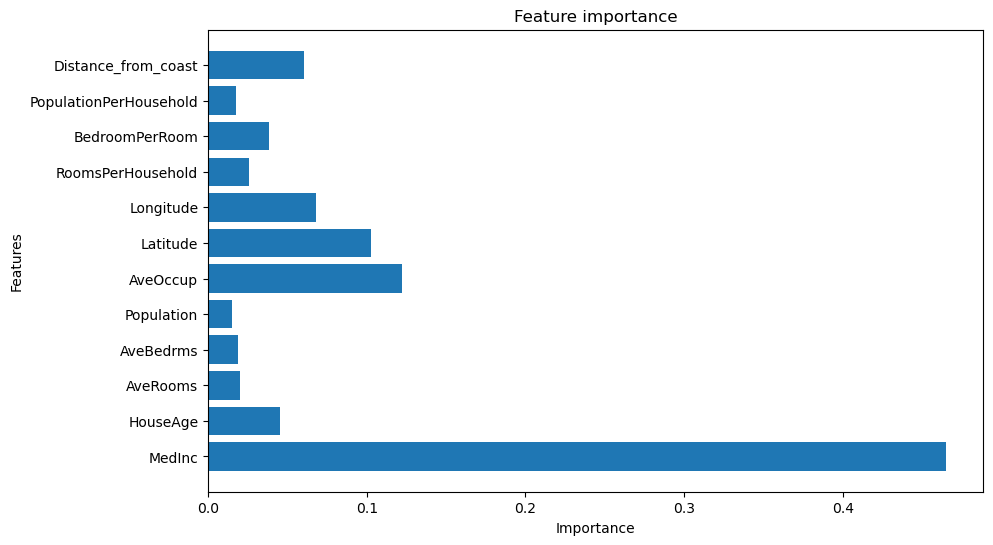

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature importance')
plt.show()